In [1]:
# =========================================================================
# 1. IMPORTS AND CONFIGURATION
# =========================================================================

# -------------------------------------------------------------------------
# 1.1. Standard Library & Third-Party Imports
# -------------------------------------------------------------------------
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple

import h5py
import numpy as np
import rasterio
from tqdm import tqdm

In [ ]:
# -------------------------------------------------------------------------
# 1.2. Configuration Dataclass
# -------------------------------------------------------------------------
@dataclass(frozen=True)
class DatasetConfig:
    # Directory paths
    input_dir: Path = Path("/content/drive/MyDrive/GEE_DARES_Dataset")
    output_dir: Path = Path(
        "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed"
    )

    # Patch extraction parameters
    patch_size: int = 224
    stride: int = 112

    # Quality and entropy filtering thresholds (max_nodata_ratio = max 255/invalid ratio)
    max_nodata_ratio: float = 0.10
    min_forest_ratio: float = 0.15
    max_forest_ratio: float = 0.85

    # Spatial block splitting ratios along Y-axis (Rows)
    train_ratio: float = 0.70
    val_ratio: float = 0.20
    test_ratio: float = 0.10


# =========================================================================
# 2. RASTER I/O AND PREPROCESSING UTILITIES
# =========================================================================


IGNORE_INDEX = 255


def load_raster_pair(
    image_path: Path, gt_path: Path
) -> Tuple[np.ndarray, np.ndarray]:
    """Reads image and ground truth GeoTIFF rasters into aligned NumPy arrays.

    Preserves water/wetland as 255 (ignore). Masks are {0, 1, 255}:
    1 = forest, 0 = non-forest, 255 = water/wetland/NoData (ignored).

    Synchronizes NoData masks and scales Sentinel-2 surface reflectance
    to the physical float interval [0.0, 1.0].

    Args:
        image_path: Path to the 4-band Sentinel-2 GeoTIFF.
        gt_path: Path to the 1-band Ground Truth GeoTIFF (values 0, 1, 255).

    Returns:
        Tuple of (image_array, mask_array):
            - image_array: np.ndarray of shape (4, H, W), float32.
            - mask_array: np.ndarray of shape (H, W), int16 with 255 on ignore.
    """
    with rasterio.open(image_path) as src_img:
        image = src_img.read().astype(np.float32)  # Shape: (4, H, W)
        img_nodata = src_img.nodata

    with rasterio.open(gt_path) as src_gt:
        mask = src_gt.read(1).astype(np.int16)  # Shape: (H, W), values 0, 1, 255
        gt_nodata = src_gt.nodata

    # Image NoData -> NaN (same as before)
    if img_nodata is not None:
        image[:, image[0] == img_nodata] = np.nan

    # GT: any real nodata -> 255 (ignore), NEVER -> 0
    if gt_nodata is not None:
        mask[mask == gt_nodata] = IGNORE_INDEX

    # Where the image has no valid data, the label is also ignored
    img_invalid = np.isnan(image).any(axis=0)
    mask[img_invalid] = IGNORE_INDEX

    # Normalize Sentinel-2 surface reflectance from [0, 10000] to [0.0, 1.0]
    # (only over valid image pixels; ignored pixels do not affect scaling)
    valid_pixels = image[:, ~img_invalid]
    if valid_pixels.size > 0 and np.nanmax(valid_pixels) > 10.0:
        image = image / 10000.0

    # Clip residual reflectance artifacts to strict [0.0, 1.0] interval
    image = np.clip(image, 0.0, 1.0)
    # Image NaNs -> 0 (the label there is already 255)
    image = np.nan_to_num(image, nan=0.0)

    return image, mask


# =========================================================================
# 3. PATCH EXTRACTION AND FILTERING PIPELINE
# =========================================================================


def extract_filtered_patches(
    image_block: np.ndarray, mask_block: np.ndarray, config: DatasetConfig
) -> Tuple[np.ndarray, np.ndarray]:
    """Extracts sliding window patches and applies water/NoData and entropy filters.

    Args:
        image_block: Input sub-array of shape (4, H_block, W).
        mask_block: Target sub-array of shape (H_block, W).
        config: Configuration instance with extraction parameters.

    Returns:
        Tuple of (images, masks):
            - images: np.ndarray of shape (N, 4, patch_size, patch_size), float32.
            - masks: np.ndarray of shape (N, patch_size, patch_size), uint8.
    """
    _, height, width = image_block.shape
    p_size = config.patch_size
    stride = config.stride

    extracted_images = []
    extracted_masks = []
    total_pixels = p_size * p_size

    row_coords = list(range(0, height - p_size + 1, stride))
    col_coords = list(range(0, width - p_size + 1, stride))

    for r in row_coords:
        for c in col_coords:
            img_patch = image_block[:, r : r + p_size, c : c + p_size]
            mask_patch = mask_block[r : r + p_size, c : c + p_size]

            # 1. Filter: ratio of INVALID (255 = water/wetland/NoData) < 10%
            invalid_count = (mask_patch == 255).sum()
            if (invalid_count / total_pixels) > config.max_nodata_ratio:
                continue

            valid = (mask_patch != 255)
            valid_count = valid.sum()
            if valid_count == 0:
                continue

            # 2. Filter: forest ratio in [15%, 85%] over VALID pixels only
            forest_count = (mask_patch[valid] == 1).sum()
            forest_ratio = forest_count / valid_count

            if not (
                config.min_forest_ratio <= forest_ratio <= config.max_forest_ratio
            ):
                continue

            # Sanitize image only; mask keeps 255 (uint8 preserves it)
            img_patch_clean = np.nan_to_num(img_patch, nan=0.0)

            extracted_images.append(img_patch_clean.astype(np.float32))
            extracted_masks.append(mask_patch.astype(np.uint8))

    if not extracted_images:
        return (
            np.empty((0, 4, p_size, p_size), dtype=np.float32),
            np.empty((0, p_size, p_size), dtype=np.uint8),
        )

    return np.stack(extracted_images, axis=0), np.stack(extracted_masks, axis=0)


# =========================================================================
# 4. HDF5 STORAGE AND PERSISTENCE
# =========================================================================


def save_to_hdf5(
    output_path: Path, images: np.ndarray, masks: np.ndarray
) -> None:
    """Saves image and mask arrays into a compressed HDF5 container.

    Args:
        output_path: Destination .h5 file path.
        images: Image tensor array (N, 4, 224, 224).
        masks: Mask tensor array (N, 224, 224).
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(output_path, "w") as f:
        f.create_dataset(
            "images",
            data=images,
            dtype="float32",
            chunks=(1, 4, images.shape[2], images.shape[3]),
            compression="lzf",
        )
        f.create_dataset(
            "masks",
            data=masks,
            dtype="uint8",
            chunks=(1, masks.shape[1], masks.shape[2]),
            compression="lzf",
        )


# =========================================================================
# 5. DOMAIN PROCESSING WORKFLOW
# =========================================================================


def process_domain(
    domain_name: str,
    image_filename: str,
    gt_filename: str,
    config: DatasetConfig,
) -> None:
    """Executes raster loading, Y-axis block partitioning, and HDF5 generation.

    Args:
        domain_name: Domain identifier ('source' or 'target').
        image_filename: GeoTIFF satellite image filename.
        gt_filename: GeoTIFF ground truth filename.
        config: DatasetConfig instance.
    """
    img_path = config.input_dir / image_filename
    gt_path = config.input_dir / gt_filename

    print(f"\n{'=' * 60}")
    print(f"Processing Domain: {domain_name.upper()} (Sentinel-2 10m)")
    print(f"{'=' * 60}")
    print(f"Loading: {img_path.name} and {gt_path.name}...")

    image, mask = load_raster_pair(img_path, gt_path)
    total_rows = image.shape[1]

    # Partition along Y-axis into Train (70%), Val (20%), Test (10%)
    train_end = int(total_rows * config.train_ratio)
    val_end = train_end + int(total_rows * config.val_ratio)

    splits = {
        "train": (
            slice(0, train_end),
            config.output_dir / f"{domain_name}_train.h5",
        ),
        "val": (
            slice(train_end, val_end),
            config.output_dir / f"{domain_name}_val.h5",
        ),
        "test": (
            slice(val_end, total_rows),
            config.output_dir / f"{domain_name}_test.h5",
        ),
    }

    for split_name, (row_slice, out_file) in splits.items():
        sub_image = image[:, row_slice, :]
        sub_mask = mask[row_slice, :]

        patches_img, patches_mask = extract_filtered_patches(
            sub_image, sub_mask, config
        )
        save_to_hdf5(out_file, patches_img, patches_mask)

        print(
            f"  -> [{split_name.upper()}] Saved: {len(patches_img):4d} patches | "
            f"Tensor: {patches_img.shape} | File: {out_file.name}"
        )


# =========================================================================
# 6. MAIN EXECUTION PIPELINE
# =========================================================================


def main() -> None:
    config = DatasetConfig()

    # 1. Source Domain: Brazil (São Félix do Xingu - Sentinel-2)
    process_domain(
        domain_name="source",
        image_filename="source_brasil_s2_2021_10m.tif",
        gt_filename="source_brasil_gt_2021_10m.tif",
        config=config,
    )

    # 2. Target Domain (Clean): Colombia (San José del Guaviare - Sentinel-2)
    process_domain(
        domain_name="target",
        image_filename="target_colombia_s2_2021_10m.tif",
        gt_filename="target_colombia_gt_2021_10m.tif",
        config=config,
    )

    print(f"\n{'=' * 60}")
    print("ALL DATASETS GENERATED SUCCESSFULLY IN HDF5 FORMAT")
    print(f"Output Directory: {config.output_dir}")
    print(f"{'=' * 60}")


if __name__ == "__main__":
    main()


Processing Domain: SOURCE (Sentinel-2 10m)
Loading: source_brasil_s2_10m.tif and source_brasil_gt_10m.tif...
  -> [TRAIN] Saved: 4058 patches | Tensor: (4058, 4, 224, 224) | File: source_train.h5
  -> [VAL] Saved:  984 patches | Tensor: (984, 4, 224, 224) | File: source_val.h5
  -> [TEST] Saved:  421 patches | Tensor: (421, 4, 224, 224) | File: source_test.h5

Processing Domain: TARGET (Sentinel-2 10m)
Loading: target_colombia_s2_10m.tif and target_colombia_gt_10m.tif...
  -> [TRAIN] Saved: 3837 patches | Tensor: (3837, 4, 224, 224) | File: target_train.h5
  -> [VAL] Saved:  800 patches | Tensor: (800, 4, 224, 224) | File: target_val.h5
  -> [TEST] Saved:  389 patches | Tensor: (389, 4, 224, 224) | File: target_test.h5

ALL DATASETS GENERATED SUCCESSFULLY IN HDF5 FORMAT
Output Directory: /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed


In [2]:
import h5py, numpy as np, os

base = "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed"

# (subfolder, file) -> only the 6 base splits (LIME variants share masks)
files = [
    ("Source",          "source_train.h5"),
    ("Source",          "source_val.h5"),
    ("Source",          "source_test.h5"),
    ("Target_Original", "target_train.h5"),
    ("Target_Original", "target_val.h5"),
    ("Target_Original", "target_test.h5"),
]

for subdir, name in files:
    path = os.path.join(base, subdir, name)
    if not os.path.exists(path):
        print(f"[FALTA] {subdir}/{name}")
        continue

    with h5py.File(path, "r") as h:
        masks = h["masks"]
        n = masks.shape[0]
        total = 0
        hist = {}
        for i in range(n):                      # per patch (avoids loading everything into RAM)
            m = masks[i]
            vals, counts = np.unique(m, return_counts=True)
            for v, c in zip(vals.tolist(), counts.tolist()):
                hist[v] = hist.get(v, 0) + c
            total += m.size

    print(f"\n=== {subdir}/{name} | parches: {n} | píxeles: {total:,} ===")
    for v in sorted(hist):
        print(f"   valor {v:>3}: {hist[v]:>12,} ({100*hist[v]/total:6.2f}%)")
    if 255 not in hist:
        print("   [WARNING] value 255 MISSING: water/wetland -> 255 change NOT applied in this split")
    else:
        print(f"   [OK] 255 present: {100*hist[255]/total:.2f}% (expected ~1-2%)")


=== Source/source_train.h5 | parches: 4058 | píxeles: 203,614,208 ===
   valor   0:  114,134,216 ( 56.05%)
   valor   1:   89,479,992 ( 43.95%)

=== Source/source_val.h5 | parches: 984 | píxeles: 49,373,184 ===
   valor   0:   26,665,560 ( 54.01%)
   valor   1:   22,707,624 ( 45.99%)

=== Source/source_test.h5 | parches: 421 | píxeles: 21,124,096 ===
   valor   0:   11,921,400 ( 56.44%)
   valor   1:    9,202,696 ( 43.56%)

=== Target_Original/target_train.h5 | parches: 3837 | píxeles: 192,525,312 ===
   valor   0:  100,055,659 ( 51.97%)
   valor   1:   92,469,653 ( 48.03%)

=== Target_Original/target_val.h5 | parches: 800 | píxeles: 40,140,800 ===
   valor   0:   19,126,547 ( 47.65%)
   valor   1:   21,014,253 ( 52.35%)

=== Target_Original/target_test.h5 | parches: 389 | píxeles: 19,518,464 ===
   valor   0:   10,022,111 ( 51.35%)
   valor   1:    9,496,353 ( 48.65%)


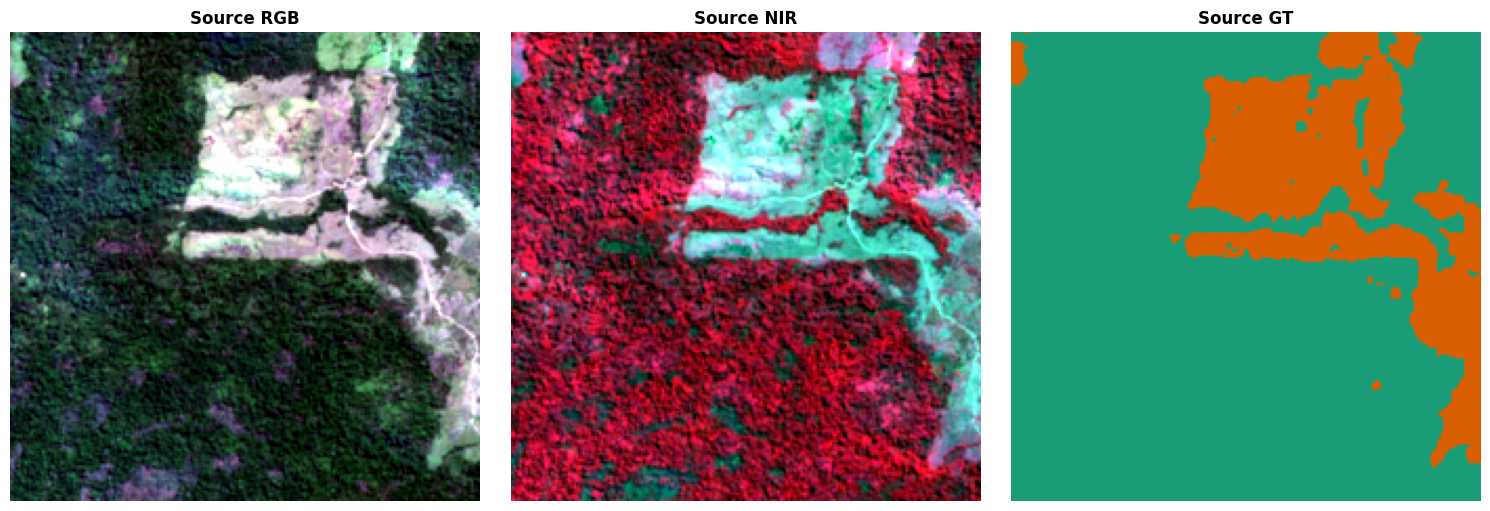

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Source configuration
SOURCE_H5 = "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Source/source_val.h5"
IDX = 0

with h5py.File(SOURCE_H5, "r") as f:
    img = f["images"][IDX]
    mask = f["masks"][IDX]

img_hwc = np.transpose(img, (1, 2, 0))

def stretch(b):
    v_min, v_max = np.percentile(b, (2, 98))
    return np.clip((b - v_min) / (v_max - v_min), 0, 1) if v_max > v_min else np.zeros_like(b)

rgb = np.stack([stretch(img_hwc[:,:,2]), stretch(img_hwc[:,:,1]), stretch(img_hwc[:,:,0])], axis=-1)
nir = np.stack([stretch(img_hwc[:,:,3]), stretch(img_hwc[:,:,2]), stretch(img_hwc[:,:,1])], axis=-1)
cmap = ListedColormap(["#d95f02", "#1b9e77"])

# Layout synchronization: 1x3 grid without colorbar to match target grid height consistency
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Standardized titles matching target cell pattern
axes[0].imshow(rgb)
axes[0].set_title("Source RGB", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(nir)
axes[1].set_title("Source NIR", fontsize=12, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(mask, cmap=cmap, vmin=0, vmax=1)
axes[2].set_title("Source GT", fontsize=12, fontweight="bold")
axes[2].axis("off")

# Save figure
plt.savefig("source_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

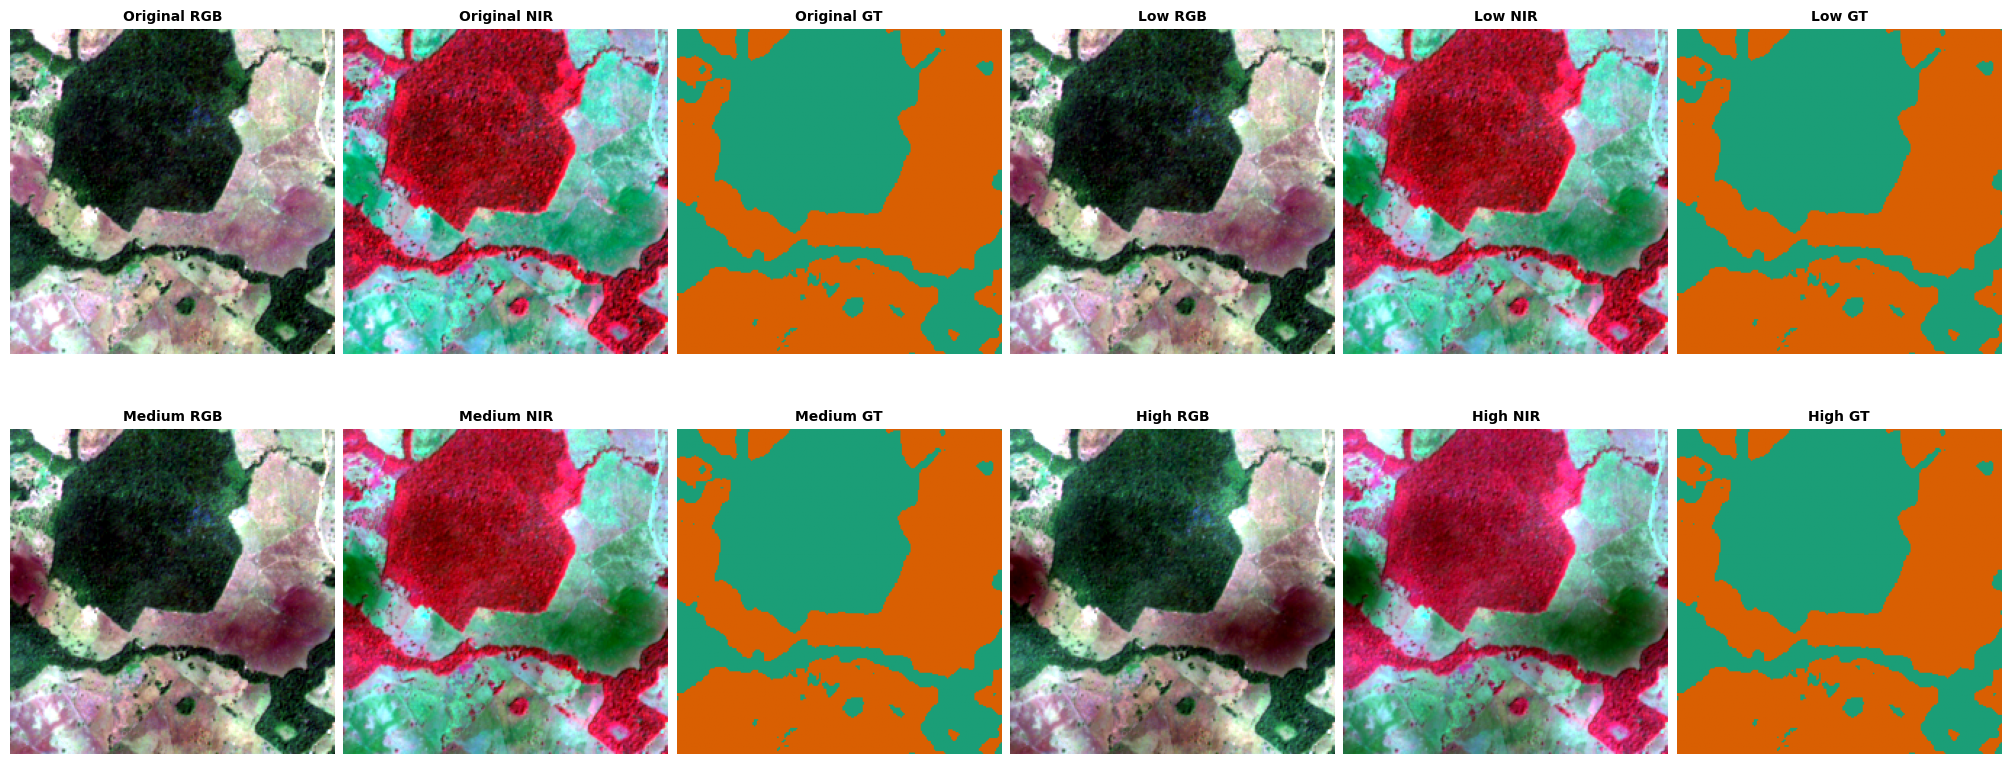

In [ ]:
paths = {
    "Original": "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Original/target_val.h5",
    "Low": "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Low/target_val_lime_low.h5",
    "Medium": "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Medium/target_val_lime_med.h5",
    "High": "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_High/target_val_lime_high.h5"
}

IDX = 2
# 2 rows, 6 columns grid
fig, axes = plt.subplots(2, 6, figsize=(20, 8), constrained_layout=True)

levels = [("Original", 0, 0), ("Low", 0, 3), ("Medium", 1, 0), ("High", 1, 3)]

for name, row, col_start in levels:
    with h5py.File(paths[name], "r") as f:
        img = f["images"][IDX]
        mask = f["masks"][IDX]

    img_hwc = np.transpose(img, (1, 2, 0))
    rgb = np.stack([stretch(img_hwc[:,:,2]), stretch(img_hwc[:,:,1]), stretch(img_hwc[:,:,0])], axis=-1)
    nir = np.stack([stretch(img_hwc[:,:,3]), stretch(img_hwc[:,:,2]), stretch(img_hwc[:,:,1])], axis=-1)

    # Plot RGB
    axes[row, col_start].imshow(rgb)
    axes[row, col_start].set_title(f"{name} RGB", fontsize=10, fontweight='bold')
    axes[row, col_start].axis("off")

    # Plot NIR
    axes[row, col_start + 1].imshow(nir)
    axes[row, col_start + 1].set_title(f"{name} NIR", fontsize=10, fontweight='bold')
    axes[row, col_start + 1].axis("off")

    # Plot GT
    im_gt = axes[row, col_start + 2].imshow(mask, cmap=cmap, vmin=0, vmax=1)
    axes[row, col_start + 2].set_title(f"{name} GT", fontsize=10, fontweight='bold')
    axes[row, col_start + 2].axis("off")

# Save with high quality
plt.savefig("target_perturbation_grid.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# =========================================================================
# 1. IMPORTS AND CONFIGURATION
# =========================================================================

import zlib
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Tuple

import cv2
import h5py
import numpy as np
from tqdm import tqdm


@dataclass(frozen=True)
class LimePerturbationConfig:
    # Directorios de datos
    data_dir: Path = Path("/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed")

    # Niveles de severidad y muestreo discreto por nivel
    severity_levels: Dict[str, Tuple[float, ...]] = field(
        default_factory=lambda: {
            "low": (0.1, 0.2),
            "med": (0.3, 0.4, 0.5),
            "high": (0.6, 0.7),
        }
    )

    # Hiperparámetros del Guided Filter para el mapa de iluminación T(x)
    gf_radius: int = 15
    gf_eps: float = 1e-3
    eps_div: float = 1e-6
    gamma_scale: float = 3.5

    # Semilla para reproducibilidad del muestreo de severidad
    seed: int = 42


# =========================================================================
# 2. GUIDED FILTER NATIVO (SIN XIMGPROC / DEPENDENCIAS EXTRA)
# =========================================================================


def guided_filter_2d(
    guide: np.ndarray, src: np.ndarray, radius: int, eps: float
) -> np.ndarray:
    """Implementación canónica de Guided Filter (He et al., 2013) usando cv2.boxFilter.

    Args:
        guide: Imagen guía 2D (H, W), float32.
        src: Imagen de entrada a filtrar 2D (H, W), float32.
        radius: Radio de la ventana de filtrado.
        eps: Parámetro de regularización.

    Returns:
        np.ndarray de salida suavizado (H, W), float32.
    """
    ksize = (2 * radius + 1, 2 * radius + 1)

    # Medias locales
    mean_i = cv2.boxFilter(guide, cv2.CV_32F, ksize)
    mean_p = cv2.boxFilter(src, cv2.CV_32F, ksize)
    mean_ip = cv2.boxFilter(guide * src, cv2.CV_32F, ksize)
    cov_ip = mean_ip - (mean_i * mean_p)

    # Varianza local de la guía
    mean_ii = cv2.boxFilter(guide * guide, cv2.CV_32F, ksize)
    var_i = mean_ii - (mean_i * mean_i)

    # Coeficientes lineales a y b
    a = cov_ip / (var_i + eps)
    b = mean_p - (a * mean_i)

    # Medias de coeficientes
    mean_a = cv2.boxFilter(a, cv2.CV_32F, ksize)
    mean_b = cv2.boxFilter(b, cv2.CV_32F, ksize)

    # Reconstrucción guiada
    return (mean_a * guide) + mean_b


# =========================================================================
# 3. LIME RETINEX OPERATOR (MULTISPECTRAL S2)
# =========================================================================


def apply_lime_patch(
    image: np.ndarray, severity: float, config: LimePerturbationConfig
) -> np.ndarray:
    """Aplica atenuación de iluminación LIME sobre un parche multiespectral de 4 bandas.

    Args:
        image: Array de entrada (4, H, W) en rango [0.0, 1.0], float32.
        severity: Factor escalar de severidad de perturbación.
        config: Instancia con hiperparámetros del operador.

    Returns:
        np.ndarray de forma (4, H, W), float32, recortado en [0.0, 1.0].
    """
    # 1. Estimación inicial del mapa de iluminación T_0 (máximo entre bandas)
    t_init = np.max(image, axis=0).astype(np.float32)

    # 2. Guía para el filtro (promedio de bandas visibles B2, B3, B4)
    guide = np.mean(image[:3, :, :], axis=0).astype(np.float32)

    # 3. Refinamiento espacial mediante Guided Filter nativo
    t_refined = guided_filter_2d(
        guide=guide,
        src=t_init,
        radius=config.gf_radius,
        eps=config.gf_eps,
    )

    # Estabilizar límites físicos de transmitancia
    t_refined = np.clip(t_refined, 0.01, 1.0)

    # 4. Modulación por exponente gamma y factor de atenuación
    gamma = 1.0 + (severity * config.gamma_scale)
    attenuation_map = np.power(t_refined, gamma) / (
        t_refined + config.eps_div
    )

    # 5. Modulación espectral y recorte en [0.0, 1.0]
    perturbed_image = image * attenuation_map[np.newaxis, :, :]
    return np.clip(perturbed_image, 0.0, 1.0).astype(np.float32)


# =========================================================================
# 4. HDF5 BATCH GENERATION PIPELINE
# =========================================================================


def process_hdf5_split(
    split_name: str,
    level_name: str,
    severity_pool: Tuple[float, ...],
    config: LimePerturbationConfig,
    rng: np.random.Generator,
) -> None:
    """Lee el split limpio de Target, perturba los parches y genera el HDF5 degradado."""
    input_file = config.data_dir / f"target_{split_name}.h5"
    output_file = config.data_dir / f"target_{split_name}_lime_{level_name}.h5"

    if not input_file.exists():
        print(f"[-] Saltando {input_file.name}: Archivo no encontrado.")
        return

    with h5py.File(input_file, "r") as src_h5:
        images = src_h5["images"][:]
        masks = src_h5["masks"][:]

    n_samples, channels, height, width = images.shape
    perturbed_images = np.empty_like(images, dtype=np.float32)

    # Muestreo discreto determinista de severidad por muestra
    severities = rng.choice(severity_pool, size=n_samples)

    for i in tqdm(
        range(n_samples),
        desc=f"[{split_name.upper()}] LIME-{level_name.upper()}",
        ncols=80,
    ):
        perturbed_images[i] = apply_lime_patch(
            image=images[i],
            severity=float(severities[i]),
            config=config,
        )

    # Guardar en HDF5 con compresión LZF
    with h5py.File(output_file, "w") as dst_h5:
        dst_h5.create_dataset(
            "images",
            data=perturbed_images,
            dtype="float32",
            chunks=(1, channels, height, width),
            compression="lzf",
        )
        dst_h5.create_dataset(
            "masks",
            data=masks,
            dtype="uint8",
            chunks=(1, height, width),
            compression="lzf",
        )

    print(
        f"  -> Guardado: {output_file.name} | "
        f"Muestras: {n_samples} | Pool: {severity_pool}"
    )


# =========================================================================
# 5. ENTRY POINT
# =========================================================================


def main() -> None:
    config = LimePerturbationConfig()
    splits = ["train", "val", "test"]

    print("=" * 65)
    print("GENERADOR DE PERTURBACIONES LIME PARA DOMINIO TARGET")
    print(f"Directorio: {config.data_dir}")
    print("=" * 65)

    for level_name, severity_pool in config.severity_levels.items():
        print(
            f"\n>>> Nivel: {level_name.upper()} (Opciones: {severity_pool}) <<<"
        )
        rng = np.random.default_rng(
            config.seed + zlib.crc32(level_name.encode()) % 1000
        )

        for split in splits:
            process_hdf5_split(
                split_name=split,
                level_name=level_name,
                severity_pool=severity_pool,
                config=config,
                rng=rng,
            )

    print("\n" + "=" * 65)
    print("TODAS LAS VARIANTES LIME HAN SIDO GENERADAS EXITOSAMENTE")
    print("=" * 65)


if __name__ == "__main__":
    main()

GENERADOR DE PERTURBACIONES LIME PARA DOMINIO TARGET
Directorio: /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed

>>> Nivel: LOW (Opciones: (0.1, 0.2)) <<<


[TRAIN] LIME-LOW: 100%|████████████████████| 3837/3837 [00:19<00:00, 197.61it/s]


  -> Guardado: target_train_lime_low.h5 | Muestras: 3837 | Pool: (0.1, 0.2)


[VAL] LIME-LOW: 100%|████████████████████████| 800/800 [00:05<00:00, 144.83it/s]


  -> Guardado: target_val_lime_low.h5 | Muestras: 800 | Pool: (0.1, 0.2)


...

  -> Guardado: target_train_lime_high.h5 | Muestras: 3837 | Pool: (0.6, 0.7)


[VAL] LIME-HIGH: 100%|███████████████████████| 800/800 [00:02<00:00, 279.42it/s]


  -> Guardado: target_val_lime_high.h5 | Muestras: 800 | Pool: (0.6, 0.7)


[TEST] LIME-HIGH: 100%|██████████████████████| 389/389 [00:02<00:00, 139.03it/s]


  -> Guardado: target_test_lime_high.h5 | Muestras: 389 | Pool: (0.6, 0.7)

TODAS LAS VARIANTES LIME HAN SIDO GENERADAS EXITOSAMENTE


In [ ]:
!ls -R /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed:
Source	Target_High  Target_Low  Target_Medium	Target_Original

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Source:
source_test.h5	source_train.h5  source_val.h5

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_High:
target_test_lime_high.h5  target_train_lime_high.h5  target_val_lime_high.h5

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Low:
target_test_lime_low.h5  target_train_lime_low.h5  target_val_lime_low.h5

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Medium:
target_test_lime_med.h5  target_train_lime_med.h5  target_val_lime_med.h5

/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed/Target_Original:
target_test.h5	target_train.h5  target_val.h5


In [ ]:
# =========================================================================
# COMPRESIÓN ZIP DEL DATASET HDF5 (DARES BENCHMARK)
# =========================================================================

from pathlib import Path
import zipfile
from tqdm import tqdm

# -------------------------------------------------------------------------
# 1. Rutas de entrada y salida
# -------------------------------------------------------------------------
source_dir = Path("/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed")
output_zip = Path(
    "/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed.zip"
)

# -------------------------------------------------------------------------
# 2. Recolección de archivos .h5
# -------------------------------------------------------------------------
if not source_dir.exists():
    raise FileNotFoundError(f"No se encontró el directorio: {source_dir}")

# Obtener todos los archivos dentro de las subcarpetas
files_to_zip = sorted([f for f in source_dir.rglob("*") if f.is_file()])

print("=" * 65)
print(f"Carpeta origen : {source_dir}")
print(f"Archivo destino: {output_zip}")
print(f"Total archivos : {len(files_to_zip)} archivos .h5 encontrados")
print("=" * 65)

# -------------------------------------------------------------------------
# 3. Creación del archivo ZIP
# -------------------------------------------------------------------------
# Usamos ZIP_STORED (sin compresión adicional) ya que los h5 usan LZF interna.
# Para forzar compresión deflate estándar, usa: compression=zipfile.ZIP_DEFLATED
with zipfile.ZipFile(
    output_zip, "w", compression=zipfile.ZIP_STORED
) as zipf:
    for file_path in tqdm(
        files_to_zip, desc="Empaquetando HDF5 en .zip", ncols=80
    ):
        # arcname preserva la ruta relativa (ej. Target_Low/target_train_lime_low.h5)
        relative_path = file_path.relative_to(source_dir)
        zipf.write(file_path, arcname=str(relative_path))

# -------------------------------------------------------------------------
# 4. Resumen y verificación
# -------------------------------------------------------------------------
zip_size_gb = output_zip.stat().st_size / (1024**3)
print("\n" + "=" * 65)
print(f"COMPRESIÓN COMPLETADA EXITOSAMENTE")
print(f"Archivo generado : {output_zip.name}")
print(f"Tamaño total     : {zip_size_gb:.2f} GB")
print("=" * 65)

Carpeta origen : /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed
Archivo destino: /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed.zip
Total archivos : 15 archivos .h5 encontrados


Empaquetando HDF5 en .zip: 100%|████████████████| 15/15 [04:44<00:00, 18.95s/it]



COMPRESIÓN COMPLETADA EXITOSAMENTE
Archivo generado : hdf5_processed.zip
Tamaño total     : 16.23 GB


In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
kagglehub.dataset_upload(
    'lucasiturriago/dares-amazon-uda',
    '/content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed.zip')

Uploading Dataset https://kaggle.com/datasets/lucasiturriago/dares-amazon-uda ...
Starting upload for file /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed.zip


Uploading: 100%|██████████| 17.4G/17.4G [02:41<00:00, 108MB/s]

Upload successful: /content/drive/MyDrive/GEE_DARES_Dataset/hdf5_processed.zip (16GB)


Your dataset has been created.
Files are being processed...
See at: https://kaggle.com/datasets/lucasiturriago/dares-amazon-uda
